# Model Experiments

## Objective

This notebook focuses on building and comparing multiple machine learning models using only textual information from job postings.

The workflow includes:

- Text preprocessing
- TF-IDF vectorization
- Baseline model training
- Model comparison
- Selection of the best model for hyperparameter tuning

Only the merged text feature is used throughout this notebook to simulate the production deployment scenario.

## Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/fake_job_postings.csv")

In [4]:
TEXT_COLUMNS = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

In [5]:
df[TEXT_COLUMNS] = df[TEXT_COLUMNS].fillna("")

In [6]:
df["text"] = df[TEXT_COLUMNS].agg(" ".join, axis=1)

In [7]:
X = df["text"]

y = df["fraudulent"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Why split before preprocessing?

To prevent data leakage, preprocessing steps that learn from data (such as TF-IDF) are fit only on the training set and then applied to the test set.

# Text Preprocessing

The raw text contains HTML tags, URLs, email addresses, punctuation, special characters, inconsistent casing, and unnecessary whitespace.

The preprocessing pipeline aims to standardize the text while preserving meaningful information for classification.

### Steps

- Convert text to lowercase
- Remove HTML tags
- Normalize unicode characters
- Remove URLs
- Remove email addresses
- Remove punctuation
- Remove numbers
- Remove extra whitespace
- Remove stopwords
- Perform POS-aware lemmatization

In [9]:
import re
import string
import unicodedata

from bs4 import BeautifulSoup

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag

In [10]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("averaged_perceptron_tagger")
nltk.download("omw-1.4")


[nltk_data] Downloading package punkt to /home/user/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/user/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/user/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/user/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /home/user/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [11]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

In [12]:
def get_wordnet_pos(tag):

    if tag.startswith("J"):
        return wordnet.ADJ

    elif tag.startswith("V"):
        return wordnet.VERB

    elif tag.startswith("N"):
        return wordnet.NOUN

    elif tag.startswith("R"):
        return wordnet.ADV

    return wordnet.NOUN

In [13]:
def preprocess_text(text):
    """
    Cleans and preprocesses raw job posting text.
    """

    # Handle missing values
    if pd.isna(text):
        return ""

    # Lowercase
    text = text.lower()

    # Replace non-breaking spaces
    text = text.replace("\xa0", " ")

    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # Normalize unicode characters
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("utf-8")

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|#url_\w+#", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Dataset-specific cleaning (MS Office artifacts)
    text = re.sub(r"\bmso\b", " ", text)
    text = re.sub(r"\b\d*pt\b", " ", text)
    text = re.sub(r"\b\d*in\b", " ", text)

    # Remove standalone numbers
    text = re.sub(r"\b\d+\b", " ", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = nltk.word_tokenize(text)

    # POS tagging
    tagged_words = pos_tag(words)

    # Lemmatization + Stopword Removal
    cleaned_words = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged_words
        if word not in stop_words and len(word) > 1
    ]

    return " ".join(cleaned_words).strip()

In [14]:
X_train = X_train.apply(preprocess_text)

X_test = X_test.apply(preprocess_text)

In [15]:
print(X_train.iloc[0])

contact center representative tidewater finance co establish initial purpose purchasing service retail installment contract two division tidewater credit service provide indirect consumer retail finance option tidewater motor credit provide indirect consumer auto financing remain committed offer partnership dealer consumer create winwinwin situation success rely solely success dealer consumersfull time position include following benefit vacation hour month employment vacation hour year employment6 pay holiday well anniversary holiday benefitpaid personal sick leave day employmentfull benefit include health dental life disability insurancea 401k plan company match month employment base upon quarterly entry dateincentive bonus individual team goal certain positionsbilingual spanish eligible differential pay tidewater finance company locate virginia beach va full parttime position available contact center representative provide diverse lending solution dealer network promote employee inte

# TF-IDF Feature Extraction

Machine Learning models cannot process raw text directly. Therefore, the cleaned text must be converted into numerical feature vectors.

This project uses **Term Frequency–Inverse Document Frequency (TF-IDF)**, which assigns higher importance to words that are frequent within a document but relatively rare across the entire corpus.

### Why TF-IDF?

- Simple and computationally efficient.
- Works exceptionally well with linear machine learning models.
- Produces sparse feature vectors suitable for high-dimensional text classification.
- Serves as a strong baseline before considering deep learning approaches.

### Selected Parameters

- max_features = 10000
- ngram_range = (1,2)
- min_df = 2
- max_df = 0.95

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

In [17]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [18]:
print("Training Shape :", X_train_tfidf.shape)
print("Testing Shape :", X_test_tfidf.shape)

Training Shape : (14304, 10000)
Testing Shape : (3576, 10000)


In [19]:
print(f"Vocabulary Size: {len(tfidf.vocabulary_):,}")

Vocabulary Size: 10,000


In [20]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:30])

['00am' '00pm' '100k' '1st' '21st' '21st century' '24x7' '2nd' '3d'
 '3d printing' '3rd' '3rd party' '401k' '401k company' '401k plan' '9am'
 '9am isnt' 'aan' 'ab' 'ab test' 'abc' 'abc supply' 'ability'
 'ability adapt' 'ability build' 'ability communicate' 'ability deliver'
 'ability demonstrate' 'ability develop' 'ability effectively']


### Key Observations

- TF-IDF successfully converted textual data into sparse numerical vectors.
- The vectorizer was fit only on the training data to avoid data leakage.
- Both unigrams and bigrams are included to capture meaningful word combinations.

# Baseline Model Training

Five machine learning algorithms are evaluated using the same TF-IDF features.

The objective is to identify the model that provides the best balance between Precision, Recall, F1-score, and ROC-AUC for the highly imbalanced dataset.

The evaluated models are:

- Logistic Regression
- Multinomial Naive Bayes
- Linear Support Vector Machine
- Random Forest
- XGBoost

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import time

In [22]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Naive Bayes": MultinomialNB(),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )
}

In [23]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    start = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
    else:
        y_prob = y_pred

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Training Time (s)": train_time
    }

In [24]:
results = []

for name, model in models.items():

    print(f"Training {name}...")

    metrics = evaluate_model(
        model,
        X_train_tfidf,
        X_test_tfidf,
        y_train,
        y_test
    )

    metrics["Model"] = name

    results.append(metrics)

Training Logistic Regression...
Training Naive Bayes...
Training Linear SVM...
Training Random Forest...
Training XGBoost...


In [25]:
results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Training Time (s)"
    ]
]

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (s)
2,Linear SVM,0.984340,0.850299,0.820809,0.835294,0.980400,2.155872
4,XGBoost,0.979866,0.825806,0.739884,0.780488,0.973808,51.649266
3,Random Forest,0.980984,0.920000,0.664740,0.771812,0.988539,3.729131
0,Logistic Regression,0.972036,0.659389,0.872832,0.751244,0.981942,0.276708
1,Naive Bayes,0.960291,0.706667,0.306358,0.427419,0.931594,0.025125


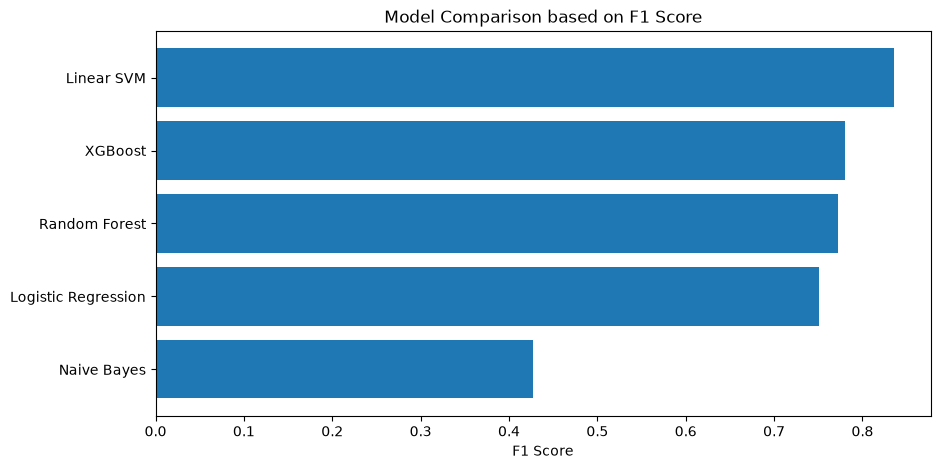

In [26]:
results_df.sort_values(
    by="F1 Score",
    inplace=True
)

plt.figure(figsize=(10,5))

plt.barh(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.title("Model Comparison based on F1 Score")

plt.xlabel("F1 Score")

plt.show()

# Model Comparison Summary

## Results

| Model | Observation |
|-------|-------------|
| Logistic Regression | Strong baseline with high recall and fast training. |
| Naive Bayes | Fastest model but poor minority class performance. |
| Linear SVM | Best overall F1-score with competitive ROC-AUC. |
| Random Forest | Strong ROC-AUC but lower Recall and F1-score. |
| XGBoost | Good performance but significantly longer training time. |

---

## Selected Models for Further Investigation

Based on the evaluation metrics:

- ✅ Linear SVM
- ✅ XGBoost

These models will be further analyzed and tuned in the next notebook.